In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
nav_history=pd.read_csv(r"C:\Users\aksha\OneDrive\Desktop\BLUE STOCK INTERNSHIP\Mutual-Fund-Analysis\data\processed\nav_history_cleaned.csv")
fund_master=pd.read_csv(r"C:\Users\aksha\OneDrive\Desktop\BLUE STOCK INTERNSHIP\Mutual-Fund-Analysis\data\processed\fund_master_cleaned.csv")

In [3]:
nav_history.dtypes

amfi_code      int64
date             str
nav          float64
dtype: object

In [4]:
fund_master.dtypes

amfi_code               int64
fund_house                str
scheme_name               str
category                  str
sub_category              str
plan                      str
launch_date               str
benchmark                 str
expense_ratio_pct     float64
exit_load_pct         float64
min_sip_amount          int64
min_lumpsum_amount      int64
fund_manager              str
risk_category             str
sebi_category_code        str
dtype: object

In [5]:
nav_history['date']=pd.to_datetime(nav_history['date'])

In [6]:
fund_master['launch_date']=pd.to_datetime(fund_master['launch_date'])

In [7]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [8]:
nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [9]:
# compute daily return for all schemes
nav_history=nav_history.sort_values(['amfi_code','date']).reset_index(drop=False)

In [10]:
# calculating daily returns
nav_history['daily_return']=nav_history.groupby('amfi_code')['nav'].pct_change()
nav_history.head()

,index,amfi_code,date,nav,daily_return
0,5750,100016,2022-01-03,520.4608,NaN
1,5751,100016,2022-01-04,515.0971,-0.010306
2,5752,100016,2022-01-05,521.7239,0.012865
3,5753,100016,2022-01-06,515.7880,-0.011377
4,5754,100016,2022-01-07,515.1639,-0.001210


In [11]:
# VaR (95%) and CVaR for all 40 schemes
var_cvar = nav_history.groupby('amfi_code')['daily_return'].quantile(0.05).reset_index()
var_cvar.columns = ['amfi_code', 'var_95']

var_cvar.head()

,amfi_code,var_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [12]:
cvar_list = []

for code in var_cvar['amfi_code']:
    threshold = var_cvar.loc[var_cvar['amfi_code'] == code, 'var_95'].values[0]
    fund_returns = nav_history.loc[nav_history['amfi_code'] == code, 'daily_return']
    cvar_value = fund_returns[fund_returns <= threshold].mean()
    cvar_list.append(cvar_value)

var_cvar['cvar_95'] = cvar_list

var_cvar.head()

,amfi_code,var_95,cvar_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [13]:
# merging fund master data and var_car
var_cvar_report = var_cvar.merge(fund_master[['amfi_code', 'scheme_name', 'category', 'risk_category']], on='amfi_code', how='left')

# Reorder columns nicely
var_cvar_report = var_cvar_report[['amfi_code', 'scheme_name', 'category', 'risk_category', 'var_95', 'cvar_95']]

var_cvar_report.head()

,amfi_code,scheme_name,category,risk_category,var_95,cvar_95
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Moderate,-0.014364,-0.018060
1,100025,HDFC Short Term Debt Fund - Regular - Growth,Debt,Low,-0.003793,-0.004994
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,High,-0.019034,-0.023456
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,Moderate,-0.013282,-0.017439
4,101207,ABSL Small Cap Fund - Regular - Growth,Equity,Very High,-0.026021,-0.032459


In [14]:
var_cvar_report.to_csv('../reports/var_cvar_report.csv', index=False)

##### Rolling 90-day Sharpe Ratio

In [15]:
nav_history['rolling_mean'] = nav_history.groupby('amfi_code')['daily_return'].transform(lambda x: x.rolling(90).mean())
nav_history['rolling_std'] = nav_history.groupby('amfi_code')['daily_return'].transform(lambda x: x.rolling(90).std())
nav_history['rolling_sharpe'] = (nav_history['rolling_mean'] / nav_history['rolling_std']) * np.sqrt(252)

nav_history[['amfi_code', 'date', 'daily_return', 'rolling_sharpe']].dropna().head()

,amfi_code,date,daily_return,rolling_sharpe
90,100016,2022-05-09,0.003683,-0.064787
91,100016,2022-05-10,-0.009987,-0.058880
92,100016,2022-05-11,-0.012576,-0.532521
93,100016,2022-05-12,-0.018051,-0.649005
94,100016,2022-05-13,0.006898,-0.498278


In [16]:
# Importing fund_scorecard data
fund_scorecard = pd.read_csv(r"C:\Users\aksha\OneDrive\Desktop\BLUE STOCK INTERNSHIP\Mutual-Fund-Analysis\data\processed\fund_scorecard.csv")
fund_scorecard.head()

,amfi_code,scheme_name,category,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,fund_score,overall_rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,0.340009,1.462504,0.269838,1.46,-0.112657,86.25,1
1,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,0.317775,1.190559,0.292636,1.36,-0.181885,82.25,2
2,120843,Kotak Flexicap Fund - Regular - Growth,Equity,0.295828,1.319442,0.273305,1.45,-0.129740,82.00,3
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,0.324425,1.104352,0.271954,1.38,-0.162172,80.75,4
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,Equity,0.324874,1.040569,0.211948,0.80,-0.125883,80.00,5


In [17]:
# finding the top 5 funds based on sharpe ratio
top5_funds=fund_scorecard.nlargest(5,'sharpe_ratio')
top5_funds

,amfi_code,scheme_name,category,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,fund_score,overall_rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,0.340009,1.462504,0.269838,1.46,-0.112657,86.2500,1
2,120843,Kotak Flexicap Fund - Regular - Growth,Equity,0.295828,1.319442,0.273305,1.45,-0.129740,82.0000,3
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,0.291789,1.246344,0.282704,1.60,-0.163967,73.6875,8
6,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,0.304565,1.222947,0.232010,1.54,-0.150124,74.8125,7
1,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,0.317775,1.190559,0.292636,1.36,-0.181885,82.2500,2


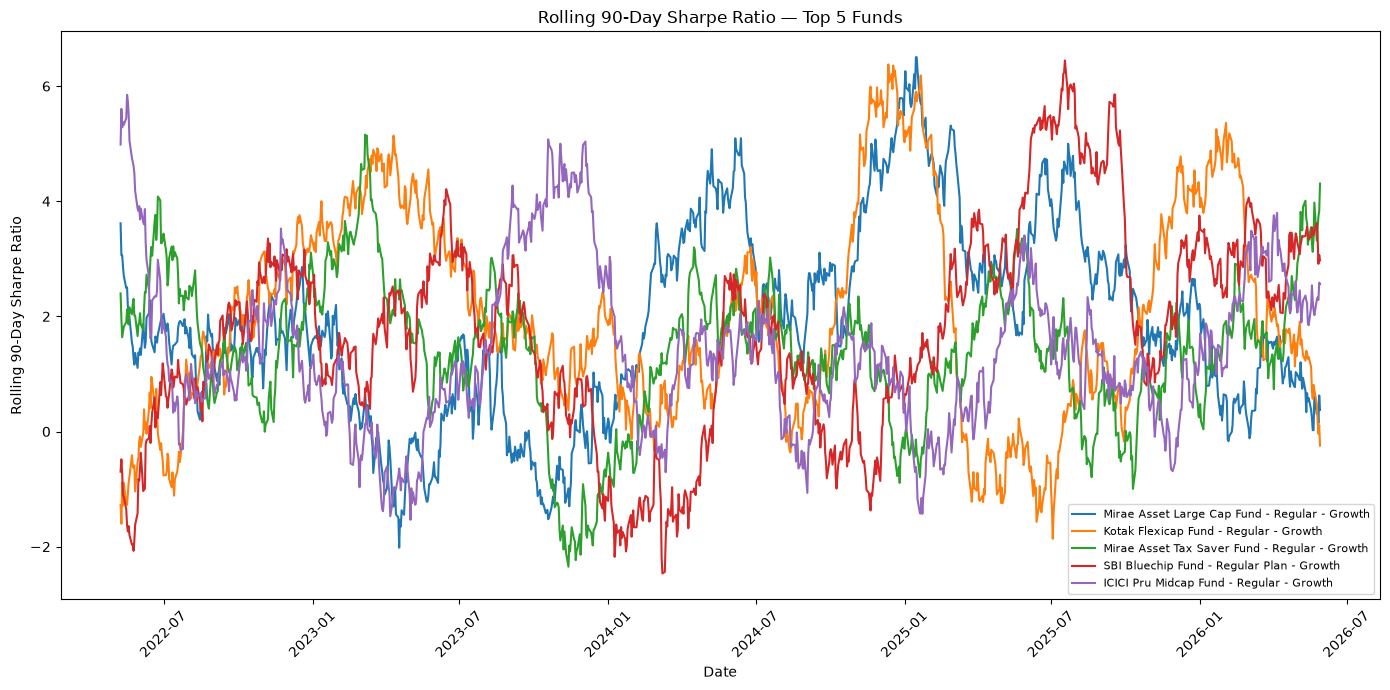

In [18]:
top5_codes = top5_funds['amfi_code'].tolist()

plt.figure(figsize=(14, 7))

for code in top5_codes:
    fund_data = nav_history[nav_history['amfi_code'] == code]
    fund_name = fund_master.loc[fund_master['amfi_code'] == code, 'scheme_name'].values[0]
    plt.plot(fund_data['date'], fund_data['rolling_sharpe'], label=fund_name)

plt.xlabel('Date')
plt.ylabel('Rolling 90-Day Sharpe Ratio')
plt.title('Rolling 90-Day Sharpe Ratio — Top 5 Funds')
plt.legend(loc='best', fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/charts/rolling_sharpe_chart.png', dpi=150)
plt.show()

##### Investor Cohort Analysis

In [19]:
investor_txn=pd.read_csv(r"C:\Users\aksha\OneDrive\Desktop\BLUE STOCK INTERNSHIP\Mutual-Fund-Analysis\data\processed\investor_transactions_cleaned.csv")
investor_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [20]:
investor_txn['transaction_date']=pd.to_datetime(investor_txn['transaction_date'])

In [21]:
# calculating the first transaction year of investors
first_txn_year=investor_txn.groupby('investor_id')['transaction_date'].min().dt.year.reset_index()
first_txn_year.head()

,investor_id,transaction_date
0,INV000001,2024
1,INV000002,2024
2,INV000003,2024
3,INV000004,2024
4,INV000005,2024


In [22]:
# changing the name
first_txn_year.columns=['investor_id','cohort_year']
first_txn_year

,investor_id,cohort_year
0,INV000001,2024
1,INV000002,2024
2,INV000003,2024
3,INV000004,2024
4,INV000005,2024
...,...,...
4995,INV004996,2024
4996,INV004997,2024
4997,INV004998,2024
4998,INV004999,2024


In [23]:
# merging the tables
investor_txn=investor_txn.merge(first_txn_year,on='investor_id',how='left')

In [24]:
investor_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [25]:
# calculating the avg sip amounts ofcohort year
avg_sip_by_cohort = investor_txn[investor_txn['transaction_type'] == 'SIP'].groupby('cohort_year')['amount_inr'].mean().reset_index()
avg_sip_by_cohort.columns = ['cohort_year', 'avg_sip_amount']

avg_sip_by_cohort

,cohort_year,avg_sip_amount
0,2024,10996.885825
1,2025,13505.209581


In [26]:
# Total invested per cohort (SIP + Lumpsum only, excluding Redemption)
invested_only = investor_txn[investor_txn['transaction_type'].isin(['SIP', 'Lumpsum'])]
total_invested_by_cohort = invested_only.groupby('cohort_year')['amount_inr'].sum().reset_index()
total_invested_by_cohort.columns = ['cohort_year', 'total_invested']

total_invested_by_cohort

,cohort_year,total_invested
0,2024,2258062304
1,2025,18992635


In [27]:
fund_counts = investor_txn.groupby(['cohort_year', 'amfi_code']).size().reset_index(name='txn_count')

fund_counts.head()

,cohort_year,amfi_code,txn_count
0,2024,100016,830
1,2024,100025,791
2,2024,100033,781
3,2024,101206,803
4,2024,101207,844


In [28]:
top_fund_per_cohort = fund_counts.sort_values('txn_count', ascending=False).groupby('cohort_year').head(1)

top_fund_per_cohort = top_fund_per_cohort.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code', how='left')

top_fund_per_cohort = top_fund_per_cohort[['cohort_year', 'scheme_name', 'txn_count']]
top_fund_per_cohort.columns = ['cohort_year', 'top_fund', 'top_fund_txn_count']

top_fund_per_cohort

,cohort_year,top_fund,top_fund_txn_count
0,2024,Mirae Asset Emerging Bluechip Fund - Regular -...,874
1,2025,ICICI Pru Liquid Fund - Regular - Growth,12


In [29]:
# creating a cohort summary table
cohort_summary = avg_sip_by_cohort.merge(total_invested_by_cohort, on='cohort_year')
cohort_summary = cohort_summary.merge(top_fund_per_cohort, on='cohort_year')

cohort_summary

,cohort_year,avg_sip_amount,total_invested,top_fund,top_fund_txn_count
0,2024,10996.885825,2258062304,Mirae Asset Emerging Bluechip Fund - Regular -...,874
1,2025,13505.209581,18992635,ICICI Pru Liquid Fund - Regular - Growth,12


##### SIP continuity analysis 

In [30]:
# Filtering sip transactions from investors transaction table
sip_txns=investor_txn[investor_txn['transaction_type']=='SIP'].copy()
sip_txns = sip_txns.sort_values(['investor_id', 'transaction_date'])
sip_txns.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024


In [31]:
# calculating the gap between days of sip transaction
sip_txns['gap_days'] = sip_txns.groupby('investor_id')['transaction_date'].diff().dt.days

sip_txns[['investor_id', 'transaction_date', 'gap_days']].head(10)

,investor_id,transaction_date,gap_days
19621,INV000001,2024-11-04,NaN
24448,INV000001,2025-01-19,76.0
5650,INV000002,2024-03-29,NaN
16803,INV000002,2024-09-21,176.0
31881,INV000002,2025-05-17,238.0
12652,INV000003,2024-07-16,NaN
27622,INV000003,2025-03-11,238.0
4773,INV000004,2024-03-16,NaN
6418,INV000004,2024-04-11,26.0
8271,INV000004,2024-05-09,28.0


In [32]:
sip_investor_stats = sip_txns.groupby('investor_id').agg(
    sip_count=('transaction_date', 'count'),
    avg_gap_days=('gap_days', 'mean')
).reset_index()

sip_investor_stats.head()

,investor_id,sip_count,avg_gap_days
0,INV000001,2,76.0
1,INV000002,3,207.0
2,INV000003,2,238.0
3,INV000004,6,85.4
4,INV000005,3,14.0


In [33]:
# Filter to investors with 6+ SIPs, then flag at-risk (avg gap > 35 days)
sip_continuity = sip_investor_stats[sip_investor_stats['sip_count'] >= 6].copy()

sip_continuity['at_risk'] = sip_continuity['avg_gap_days'] > 35

sip_continuity.head(10)

,investor_id,sip_count,avg_gap_days,at_risk
3,INV000004,6,85.400000,True
7,INV000008,6,70.400000,True
9,INV000010,6,64.800000,True
10,INV000011,7,40.166667,True
11,INV000012,8,57.000000,True
12,INV000013,7,55.333333,True
13,INV000014,7,75.333333,True
22,INV000023,8,58.571429,True
27,INV000028,6,93.600000,True
28,INV000029,7,60.666667,True


##### Simple fund recommender 

In [34]:
fund_master['risk_category'].unique()

<StringArray>
['Moderate', 'Very High', 'Low', 'High', 'Moderately High']
Length: 5, dtype: str

In [35]:
# merging the fund_scorecard table with fund_master
recommender_data = fund_scorecard.merge(fund_master[['amfi_code', 'risk_category']], on='amfi_code', how='left')

recommender_data[['amfi_code', 'scheme_name', 'risk_category', 'sharpe_ratio']].head()

,amfi_code,scheme_name,risk_category,sharpe_ratio
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.462504
1,120505,ICICI Pru Midcap Fund - Regular - Growth,High,1.190559
2,120843,Kotak Flexicap Fund - Regular - Growth,Moderately High,1.319442
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,High,1.104352
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.040569


In [36]:
risk_input = "Moderate"

matched_funds = recommender_data[recommender_data['risk_category'] == risk_input]
top3 = matched_funds.nlargest(3, 'sharpe_ratio')[['scheme_name', 'risk_category', 'sharpe_ratio']]

top3

,scheme_name,risk_category,sharpe_ratio
0,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.462504
6,SBI Bluechip Fund - Regular Plan - Growth,Moderate,1.222947
12,Nippon India Large Cap Fund - Regular - Growth,Moderate,1.095918


In [38]:
recommender_code = '''
import pandas as pd

# Load the data
fund_scorecard = pd.read_csv('data/processed/fund_scorecard.csv')
fund_master = pd.read_csv('data/processed/fund_master_cleaned.csv')

recommender_data = fund_scorecard.merge(fund_master[['amfi_code', 'risk_category']], on='amfi_code', how='left')

# Get user input
print("Enter your risk appetite: Low / Moderate / High")
risk_input = input("> ").strip().title()

# Filter and rank
matched_funds = recommender_data[recommender_data['risk_category'] == risk_input]

if matched_funds.empty:
    print("No funds found for risk category:", risk_input)
    print("Valid options are: Low, Moderate, High")
else:
    top3 = matched_funds.nlargest(3, 'sharpe_ratio')[['scheme_name', 'risk_category', 'sharpe_ratio']]
    print("\\nTop 3 Recommended Funds for", risk_input, "Risk Appetite:")
    print(top3.to_string(index=False))
'''

with open('../recommender.py', 'w') as f:
    f.write(recommender_code)

print("recommender.py updated")

recommender.py updated


##### Sector HHI concentration

In [39]:
portfolio_holdings=pd.read_csv(r"C:\Users\aksha\OneDrive\Desktop\BLUE STOCK INTERNSHIP\Mutual-Fund-Analysis\data\processed\portfolio_holding_cleaned.csv")
portfolio_holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [41]:
# Aggregate stock weights into sector weights per fund
sector_weights = portfolio_holdings.groupby(['amfi_code', 'sector'])['weight_pct'].sum().reset_index()

sector_weights.head(10)

,amfi_code,sector,weight_pct
0,100016,Automobile,14.84
1,100016,Banking,3.39
2,100016,Energy,6.09
3,100016,FMCG,11.68
4,100016,IT,25.90
5,100016,NBFC,7.01
6,100016,Pharma,25.48
7,100016,Utilities,5.61
8,100033,Automobile,26.07
9,100033,Banking,35.97


In [42]:
# Convert to fraction and compute HHI per fund
sector_weights['weight_frac'] = sector_weights['weight_pct'] / 100
sector_weights['weight_sq'] = sector_weights['weight_frac'] ** 2

hhi_by_fund = sector_weights.groupby('amfi_code')['weight_sq'].sum().reset_index()
hhi_by_fund.columns = ['amfi_code', 'hhi']

hhi_by_fund.head()

,amfi_code,hhi
0,100016,0.180588
1,100033,0.227647
2,101206,0.180042
3,101207,0.222727
4,102885,0.180712


In [43]:
# Filtering for EQUITY FUNDS only
hhi_report = hhi_by_fund.merge(fund_master[['amfi_code', 'scheme_name', 'category']], on='amfi_code', how='left')

hhi_equity = hhi_report[hhi_report['category'] == 'Equity'].sort_values('hhi', ascending=False)

hhi_equity[['amfi_code', 'scheme_name', 'hhi']]

,amfi_code,scheme_name,hhi
11,119092,Axis Bluechip Fund - Regular - Growth,0.296769
30,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.254992
27,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.253155
6,102887,UTI Flexi Cap Fund - Regular - Growth,0.251383
32,149323,DSP Midcap Fund - Regular - Growth,0.241077
21,120505,ICICI Pru Midcap Fund - Regular - Growth,0.238695
10,118635,Nippon India ETF Nifty 50 BeES,0.237497
18,119599,SBI Small Cap Fund - Direct Plan - Growth,0.232361
22,120506,ICICI Pru Value Discovery Fund - Regular - Growth,0.231464
1,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.227647


### 5 Advanced Insights in Markdown


**1. Highest Risk Funds (VaR/CVaR)**
SBI Small Cap Fund (Direct Plan) shows the highest downside risk, with a 95% VaR of -2.69% and CVaR of -3.24% — meaning on the worst 5% of trading days, this fund lost an average of over 3% in a single day. Axis Small Cap and ABSL Small Cap follow closely behind. All three highest-risk funds by this measure are Small Cap equity funds tagged "Very High" risk in fund_master — confirming the quantitative risk metrics align with the funds' own risk classification.

**2. Investor Cohort Behavior**
The 2024 investor cohort invested a combined ₹225.8 Cr (avg SIP ₹10,997), while the 2025 cohort has invested ₹1.9 Cr so far (avg SIP ₹13,505) — a smaller but higher-average-ticket group, likely reflecting fewer, newer investors who haven't yet built full transaction histories. Mirae Asset Emerging Bluechip Fund was the most-transacted fund among 2024 investors (874 SIP/lumpsum transactions), while ICICI Pru Liquid Fund led the small 2025 cohort.

**3. SIP Continuity / At-Risk Investors**
Among investors with 6+ SIP transactions (1,362 total), 97.8% (1,332 investors) show an average gap between SIPs exceeding 35 days — flagged as "at-risk" of lapsing. Only 30 investors maintained a consistent ~30-day cadence. This could reflect genuine payment inconsistency, or it may indicate the 35-day threshold is stricter than typical real-world SIP processing windows (e.g., bank holidays, mandate renewal delays) — worth validating against actual SIP due-date data if available.

**4. Sector Concentration (HHI)**
Axis Bluechip Fund is the most sector-concentrated equity fund in the dataset (HHI = 0.297), while Kotak Flexicap (0.136) and UTI Mid Cap (0.124) are the most diversified. This is consistent with fund design intent — Flexicap funds are built to spread flexibly across sectors and market caps, so a lower HHI here validates that the underlying holdings data reflects realistic portfolio construction.

**5. Rolling Sharpe Ratio Trends**
The 5 top funds show a cyclical, wave-like pattern in rolling 90-day Sharpe ratio rather than a single sustained trend — values swing repeatedly between roughly -2 and +6 across the 4+ year period. Some loose co-movement is visible (e.g., most funds trough together around early-to-mid 2024), but troughs and peaks are not perfectly synchronized across all 5 funds, and Kotak Flexicap and ICICI Pru Midcap often move independently of the other three. Kotak Flexicap shows the sharpest peak of the group (~6.3 in early 2025). This oscillating rather than crisis-driven pattern is consistent with the dataset's synthetic generation (as also reflected in the near-zero Alpha/Beta values noted earlier), rather than a genuine market stress event.
